# Reference Dance Augmentation Precompute

각 `reference.npy`에 대해 contrastive 학습용 augment 파일들을 K개씩 생성한다.

```text
data/reference_dances/<dance>/reference.npy
  → K개의 stochastic augment
  → data/reference_dances/<dance>/augments/aug_{k:02d}.npy
  → augments/manifest.json  (파일별 seed + 어떤 op가 어떤 파라미터로 적용됐는지)
```

- 각 파일에 어떤 augment 조합이 적용됐는지 **per-file tracking**
- 한 파일도 op가 fire되지 않으면 새 시드로 **재시도**
- 모든 augment 함수 정의는 [`src/pose/augment.py`](../src/pose/augment.py)

## 0. 환경 설정

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
PROJECT_ROOT = None
for base in [start, *start.parents]:
    if (base / 'data' / 'reference_dances').exists() and (base / 'src' / 'pose' / 'augment.py').exists():
        PROJECT_ROOT = base
        break
if PROJECT_ROOT is None:
    raise RuntimeError('pjt_re project root를 찾지 못했습니다.')

sys.path.insert(0, str(PROJECT_ROOT))

from src.pose.augment import AugConfig, apply_random
from src.pose.landmark_utils import SKELETON_CONNECTIONS

REF_DIR = PROJECT_ROOT / 'data' / 'reference_dances'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('REF_DIR      =', REF_DIR)
print('dances       =', sorted(d.name for d in REF_DIR.iterdir() if d.is_dir()))

PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_re
REF_DIR      = /workspace/users/yijin/boot_env/pjt_re/data/reference_dances
dances       = ['404_dance', 'basic_movement', 'beginner_wave', 'cheerup_dance', 'freestyle_free', 'hey_mama', 'hiphop_move', 'kpop_basic', 'rasputin', 'shuffle_dance', 'smoke', 'supernova']


## 1. 설정

- `K`: 곡당 augment 파일 수
- `BASE_SEED`: 전체 재현성 시드 (곡마다 `dance_seed(name, BASE_SEED)`로 분기)
- `MIN_OPS` / `MAX_RETRIES`: op가 최소 `MIN_OPS`개 fire할 때까지 최대 `MAX_RETRIES`번 재시도
- `cfg`: 확률과 강도 범위. 필요하면 여기서 override.

In [2]:
K = 10
BASE_SEED = 42
MIN_OPS = 1
MAX_RETRIES = 20

cfg = AugConfig()
# 필요하면 여기서 override, 예:
# cfg.rot_p = 0.4
# cfg.jitter_sigma = (0.002, 0.01)

print('AugConfig:')
for k, v in cfg.__dict__.items():
    print(f'  {k:20s} = {v}')

AugConfig:
  flip_p               = 0.0
  rot_p                = 0.3
  rot_deg              = (-10.0, 10.0)
  scale_p              = 0.3
  scale_range          = (0.9, 1.1)
  shear_p              = 0.3
  shear_range          = (-0.08, 0.08)
  bone_p               = 0.3
  bone_range           = (0.95, 1.05)
  smooth_p             = 0.3
  smooth_sigma         = (0.5, 1.5)
  drop_p               = 0.3
  drop_fraction        = (0.02, 0.08)
  jitter_p             = 0.3
  jitter_sigma         = (0.003, 0.015)


## 2. 재시도 포함 생성기

`apply_random`은 확률적이라 가끔 아무 op도 fire하지 않은 결과(= 원본과 동일)가 나올 수 있다. `MIN_OPS` 이상 찍힐 때까지 새 시드로 재시도하고, 어떤 시드에서 성공했는지도 함께 기록한다.

In [3]:
def generate_one(pose, cfg, sub_seed, min_ops=1, max_retries=20):
    """Run apply_random with retries until at least min_ops fire.

    Returns: (aug_array, ops_dict, final_seed, attempts_used)
    """
    seed = int(sub_seed)
    for attempt in range(1, max_retries + 1):
        rng = np.random.default_rng(seed)
        aug, ops = apply_random(pose, cfg, rng)
        if len(ops) >= min_ops:
            return aug, ops, seed, attempt
        # Deterministic next seed for reproducibility
        seed = (seed * 2654435761 + 1) % (2**31 - 1)
    return aug, ops, seed, max_retries


def dance_seed(name: str, base: int) -> int:
    h = int(hashlib.md5(name.encode()).hexdigest()[:8], 16)
    return (base + h) % (2**31 - 1)

## 3. 전체 곡에 대해 생성

각 곡의 `augments/` 디렉터리에 `aug_{k:02d}.npy`를 저장하고 `manifest.json`에 모든 기록을 남긴다.

In [4]:
records = []
dances = sorted(d for d in REF_DIR.iterdir() if d.is_dir())

for d in dances:
    ref_path = d / 'reference.npy'
    if not ref_path.exists():
        print(f'[skip] {d.name}: reference.npy 없음')
        continue
    pose = np.load(ref_path)
    if pose.ndim != 3 or pose.shape[1] != 33 or pose.shape[2] not in (3, 4):
        print(f'[skip] {d.name}: shape {pose.shape} (expect (T, 33, 3|4))')
        continue
    if pose.shape[0] < 4:
        print(f'[skip] {d.name}: T={pose.shape[0]} too short')
        continue

    aug_dir = d / 'augments'
    aug_dir.mkdir(exist_ok=True)
    top_rng = np.random.default_rng(dance_seed(d.name, BASE_SEED))

    dance_records = []
    for k in range(K):
        sub_seed = int(top_rng.integers(0, 2**31 - 1))
        aug, ops, final_seed, attempts = generate_one(
            pose, cfg, sub_seed, min_ops=MIN_OPS, max_retries=MAX_RETRIES
        )
        out_path = aug_dir / f'aug_{k:02d}.npy'
        np.save(out_path, aug)
        rec = {
            'dance': d.name,
            'file': out_path.name,
            'n_ops': len(ops),
            'attempts': attempts,
            'initial_seed': sub_seed,
            'final_seed': final_seed,
            'ops': ops,
        }
        records.append(rec)
        dance_records.append(rec)

    manifest = {
        'dance': d.name,
        'source': str(ref_path.relative_to(PROJECT_ROOT)),
        'shape': list(pose.shape),
        'K': K,
        'base_seed': BASE_SEED,
        'min_ops': MIN_OPS,
        'config': cfg.__dict__,
        'augments': dance_records,
    }
    (aug_dir / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str))
    print(f'[{d.name}] {K}개 생성 | 평균 op = {np.mean([r["n_ops"] for r in dance_records]):.2f} | 평균 재시도 = {np.mean([r["attempts"] for r in dance_records]):.2f}')

[404_dance] 10개 생성 | 평균 op = 2.70 | 평균 재시도 = 1.10
[basic_movement] 10개 생성 | 평균 op = 2.10 | 평균 재시도 = 1.10
[beginner_wave] 10개 생성 | 평균 op = 2.20 | 평균 재시도 = 1.30
[cheerup_dance] 10개 생성 | 평균 op = 2.50 | 평균 재시도 = 1.00
[freestyle_free] 10개 생성 | 평균 op = 2.70 | 평균 재시도 = 1.10
[skip] hey_mama: reference.npy 없음
[hiphop_move] 10개 생성 | 평균 op = 2.60 | 평균 재시도 = 1.00
[kpop_basic] 10개 생성 | 평균 op = 2.00 | 평균 재시도 = 1.10
[rasputin] 10개 생성 | 평균 op = 2.80 | 평균 재시도 = 1.10
[shuffle_dance] 10개 생성 | 평균 op = 2.30 | 평균 재시도 = 1.00
[skip] smoke: T=1 too short
[skip] supernova: reference.npy 없음


## 4. 파일별 트래킹 테이블

각 row가 하나의 augment 파일. `ops` 컬럼에 어떤 op가 어떤 파라미터로 적용됐는지 전부 기록돼 있다.

In [5]:
def _op_summary(ops: dict) -> str:
    parts = []
    for name, val in ops.items():
        if isinstance(val, bool):
            parts.append(name)
        elif isinstance(val, float):
            parts.append(f'{name}={val:.3f}')
        else:
            parts.append(f'{name}={val}')
    return ', '.join(parts)

tracking = pd.DataFrame(records)
tracking['ops_summary'] = tracking['ops'].apply(_op_summary)
display_cols = ['dance', 'file', 'n_ops', 'attempts', 'final_seed', 'ops_summary']
tracking[display_cols]

,dance,file,n_ops,attempts,final_seed,ops_summary
0,404_dance,aug_00.npy,4,1,1659465400,"bone_range=[0.95, 1.05], scale=1.096, shear=[0..."
1,404_dance,aug_01.npy,2,1,165746615,"shear=[-0.05828164472874372, -0.05830886541655..."
2,404_dance,aug_02.npy,2,1,1421626596,"bone_range=[0.95, 1.05], jitter_sigma=0.010"
3,404_dance,aug_03.npy,4,1,1592547293,"bone_range=[0.95, 1.05], scale=1.038, drop_fra..."
4,404_dance,aug_04.npy,1,1,309773702,drop_fraction=0.069
...,...,...,...,...,...,...
85,shuffle_dance,aug_05.npy,3,1,1829952946,"rot_deg=-9.514, smooth_sigma=0.997, drop_fract..."
86,shuffle_dance,aug_06.npy,3,1,664918984,"bone_range=[0.95, 1.05], scale=1.059, jitter_s..."
87,shuffle_dance,aug_07.npy,1,1,1077724079,"shear=[0.053559554445496635, -0.00506901691036..."
88,shuffle_dance,aug_08.npy,3,1,416382046,"bone_range=[0.95, 1.05], drop_fraction=0.036, ..."


## 5. op별 fire rate 요약

In [6]:
all_ops = ['flip', 'bone_range', 'rot_deg', 'scale', 'shear', 'smooth_sigma', 'drop_fraction', 'jitter_sigma']
total = len(tracking)
summary = []
for op in all_ops:
    fired = tracking['ops'].apply(lambda d: op in d).sum()
    summary.append({'op': op, 'fire_rate': fired / total, 'fired': fired, 'total': total})

summary_df = pd.DataFrame(summary)
print(f'전체 파일 수: {total}')
print(f'파일당 평균 op 수   : {tracking["n_ops"].mean():.2f}')
print(f'파일당 평균 재시도 : {tracking["attempts"].mean():.2f}')
print(f'재시도 분포: {tracking["attempts"].value_counts().to_dict()}')
summary_df

전체 파일 수: 90
파일당 평균 op 수   : 2.43
파일당 평균 재시도 : 1.09
재시도 분포: {1: 83, 2: 6, 3: 1}


,op,fire_rate,fired,total
0,flip,0.000000,0,90
1,bone_range,0.355556,32,90
2,rot_deg,0.322222,29,90
3,scale,0.266667,24,90
4,shear,0.300000,27,90
5,smooth_sigma,0.433333,39,90
6,drop_fraction,0.355556,32,90
7,jitter_sigma,0.400000,36,90


## 6. 샘플 시각화

한 곡을 골라 원본과 augment 4개를 같은 프레임에서 겹쳐본다. 회전/스케일/shear가 의도대로 들어가는지 눈으로 확인.

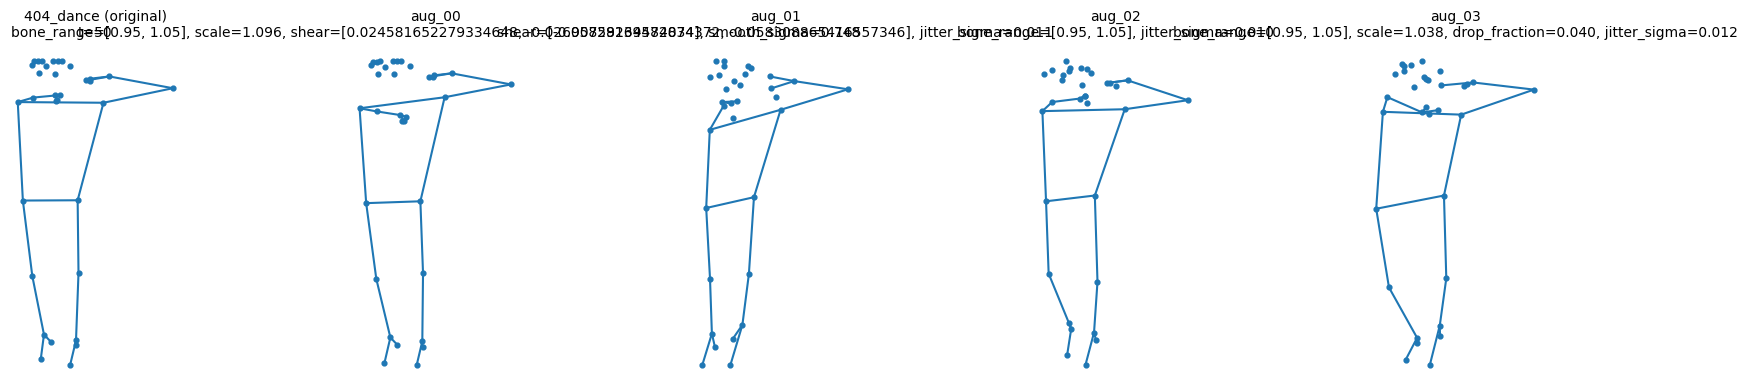

In [7]:
def plot_skeleton(ax, pose_frame, title=''):
    xs, ys = pose_frame[:, 0], pose_frame[:, 1]
    ax.scatter(xs, -ys, s=12, c='tab:blue', zorder=3)
    for a, b in SKELETON_CONNECTIONS:
        if pose_frame[a].any() and pose_frame[b].any():
            ax.plot([xs[a], xs[b]], [-ys[a], -ys[b]], 'tab:blue', lw=1.5, zorder=2)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

SAMPLE_DANCE = dances[0].name  # 원하면 다른 곡 이름으로 교체
sample_dir = REF_DIR / SAMPLE_DANCE
orig = np.load(sample_dir / 'reference.npy')

# 최초 유효 프레임 찾고 거기서 +50 프레임
t0 = next(t for t in range(len(orig)) if orig[t, 11].any())
t = min(t0 + 50, len(orig) - 1)

aug_paths = sorted((sample_dir / 'augments').glob('aug_*.npy'))[:4]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
plot_skeleton(axes[0], orig[t], f'{SAMPLE_DANCE} (original)\nt={t}')
for ax, p in zip(axes[1:], aug_paths):
    aug = np.load(p)
    rec = next(r for r in records if r['dance'] == SAMPLE_DANCE and r['file'] == p.name)
    plot_skeleton(ax, aug[t], f'{p.stem}\n{_op_summary(rec["ops"])}')
plt.tight_layout()
plt.show()